# 📦 Environment Setup & Dataset Acquisition

### 1. Library Imports
Initialized the deep learning environment with essential tools:
- **Core**: `TensorFlow`, `Keras`, `NumPy`, `Matplotlib`, `Seaborn`.
- **Pre-trained Models**: `ResNet50`, `MobileNetV2`, and **`EfficientNetB3`** (added for enhanced feature extraction).
- **Utilities**: `Scikit-learn` for metrics, `Tqdm` for progress tracking, and callbacks for training optimization (`EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`).

### 2. Dataset Download
Automated the retrieval of the **LC25000 Lung and Colon Cancer Histopathological Images** dataset using `kagglehub`.
- **Source**: `andrewmvd/lung-and-colon-cancer-histopathological-images`
- **Action**: Downloads the latest version to the local cache and prints the file path for subsequent data loading steps.

In [11]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB3
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tqdm.keras import TqdmCallback

# Scikit-learn (for evaluation metrics)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Optional (for reproducibility)
import random

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-and-colon-cancer-histopathological-images


# 🏗️ Data Pipeline: Splitting, Augmentation & Preprocessing

### 1. Dataset Splitting Strategy
- **Source**: Loaded colon histopathology images (`colon_aca`, `colon_n`) from the LC25000 dataset.
- **Split Logic**:
  - **80% Training**: Used for model learning.
  - **20% Holdout**: Further split into **10% Validation** (for hyperparameter tuning) and **10% Test** (for final unbiased evaluation).
- **Configuration**: Images resized to **224×224**, batch size **16**.

### 2. Advanced Preprocessing Pipeline
Replaced static `ImageDataGenerator` with a dynamic `tf.data` pipeline using `Sequential` layers for better performance:
- **Data Augmentation (Training Only)**:
  - 🔄 **Random Flip**: Horizontal mirroring.
  - 🌀 **Random Rotation**: ±15 degrees.
  - ↔️ **Random Translation**: 5% shift in height/width.
  - 🔍 **Random Zoom**: 10% zoom range.
- **Model-Specific Scaling**: Applied `ResNet50`'s `preprocess_input` (zero-centering based on ImageNet statistics) to all splits.

### 3. Performance Optimization
- **`.cache()`**: Stores data in memory after first epoch to prevent I/O bottlenecks.
- **`.prefetch()`**: Overlaps data loading and model training using `AUTOTUNE` for maximum GPU utilization.
- **Result**: A robust, high-throughput pipeline ready for training deep CNNs.

In [5]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers

# Path to the colon images
base_dir = "/kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets"

# Parameters
img_height, img_width = 224, 224
batch_size = 16

# Step 1: Load Training Dataset (80%)
train_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

# Step 2: Load the remaining 20% as a temporary validation set
temp_val_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

# Step 3: Split the 20% temporary set into Validation (10%) and Test (10%)
val_batches = tf.data.experimental.cardinality(temp_val_ds)
test_ds = temp_val_ds.take(val_batches // 2)
val_ds = temp_val_ds.skip(val_batches // 2)

# Data Augmentation & Preprocessing
# Translating your ImageDataGenerator request to a Sequential layer for tf.data compatibility
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(15/360), # 15 degrees
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    layers.RandomZoom(0.1),
])

def preprocess(images, labels, augment=False):
    if augment:
        images = data_augmentation(images)
    return preprocess_input(images), labels

# Class names
class_names = train_ds.class_names
label_mapping = {
    "colon_aca": "Colon adenocarcinoma",
    "colon_n": "Colon benign tissue"
}

# Step 4: Configure for performance and apply preprocessing
AUTOTUNE = tf.data.AUTOTUNE

# Apply augmentation and preprocessing to training
train_ds = train_ds.map(lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Apply preprocessing ONLY (no augmentation) to validation and test
val_ds = val_ds.map(lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.map(lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n--- Dataset Summary ---")
print(f"Number of classes: {len(class_names)}")
print(f"Training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 10000 files belonging to 2 classes.
Using 8000 files for training.
Found 10000 files belonging to 2 classes.
Using 2000 files for validation.

--- Dataset Summary ---
Number of classes: 2
Training batches: 500
Validation batches: 63
Test batches: 62


# 👁️ Visualizing Data Augmentation Effects

Demonstrated the impact of each augmentation layer on a single raw histopathology image to verify pipeline correctness:
- **Original**: Baseline image after `ResNet50` preprocessing and normalization.
- **Rotation**: Simulates varying tissue orientation (±15°).
- **Translation**: Mimics slight shifts in tissue positioning (5% width/height).
- **Zoom**: Accounts for magnification differences (10%).
- **Horizontal Flip**: Increases diversity by mirroring tissue structures.

**Purpose**: Ensures the model learns **invariant features** (e.g., cell nucleus shape, texture) rather than memorizing specific orientations or positions, crucial for robust cancer detection.

Found 10000 files belonging to 2 classes.


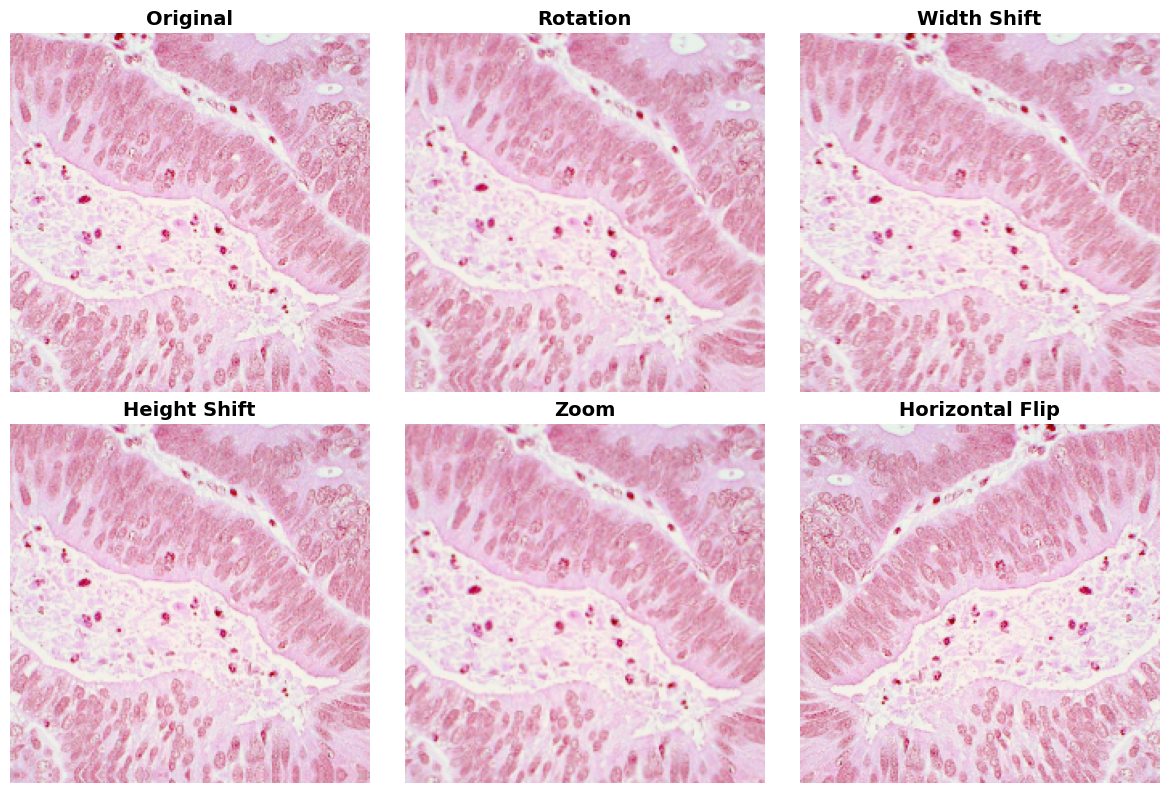

In [6]:
plt.figure(figsize=(12, 8))

# Get a single image from the training dataset (before full preprocessing)
# We'll take it from the raw directory loader to show the effect clearly
raw_train_ds = image_dataset_from_directory(
    base_dir,
    image_size=(img_height, img_width),
    batch_size=1,
    shuffle=True,
    seed=123
)

for images, labels in raw_train_ds.take(1):
    img_array = images[0] # This is a single image tensor

def get_augmented(img, layer):
    # Apply a specific layer and then ResNet50 preprocessing for consistency
    aug_img = layer(tf.expand_dims(img, 0), training=True)[0]
    aug_img = preprocess_input(aug_img).numpy()
    # Normalize to [0, 1] for visualization
    return (aug_img - aug_img.min()) / (aug_img.max() - aug_img.min() + 1e-5)

visual_steps = {
    "Original": lambda x: (preprocess_input(x).numpy() - preprocess_input(x).numpy().min()) / (preprocess_input(x).numpy().max() - preprocess_input(x).numpy().min()),
    "Rotation": layers.RandomRotation(15/360, seed=42),
    "Width Shift": layers.RandomTranslation(0, 0.05, seed=42),
    "Height Shift": layers.RandomTranslation(0.05, 0, seed=42),
    "Zoom": layers.RandomZoom(0.1, seed=42),
    "Horizontal Flip": layers.RandomFlip("horizontal", seed=42)
}

for i, (title, layer_or_func) in enumerate(visual_steps.items()):
    plt.subplot(2, 3, i + 1)

    if title == "Original":
        display_img = layer_or_func(img_array)
    else:
        display_img = get_augmented(img_array, layer_or_func)

    plt.imshow(display_img)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 👁️ Visualize Augmented Training Samples

Displayed a 3×3 grid of **randomly augmented** images from the training pipeline to verify data diversity and label integrity:
- **Visual Variation**: Each image exhibits unique transformations (rotation, flip, zoom, translation), confirming that the augmentation layer is actively generating diverse training examples.
- **Label Verification**: Titles display both the technical class name (`colon_aca`, `colon_n`) and the medical description (**Colon Adenocarcinoma**, **Benign Tissue**), ensuring labels remain correctly aligned with images after preprocessing.
- **Preprocessing Check**: Images are properly scaled and normalized for the `ResNet50`/`EfficientNet` backbone, ready for effective feature extraction.

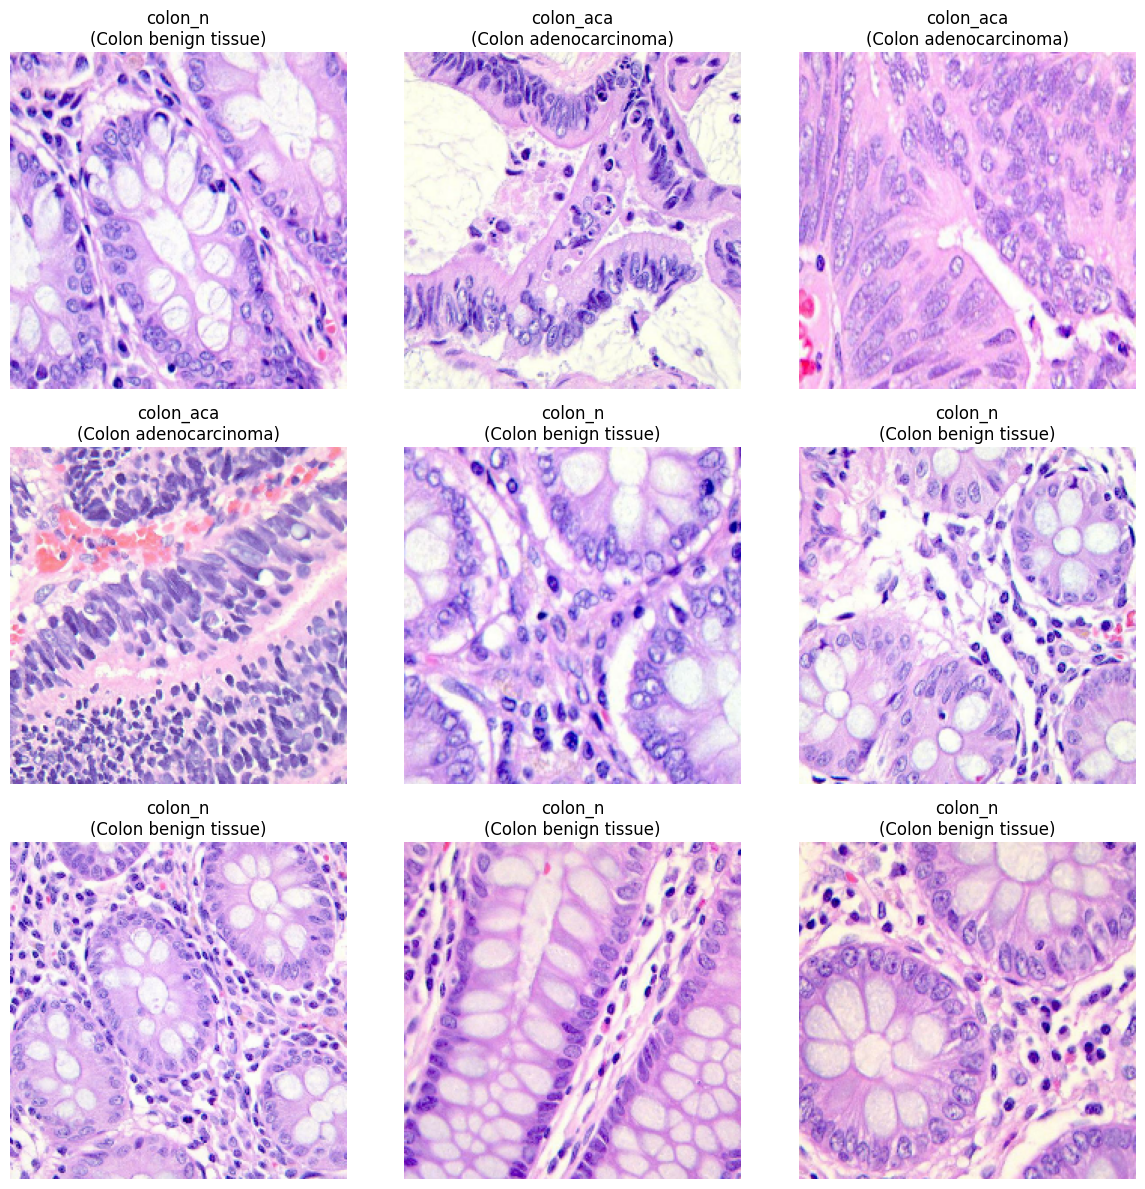

In [4]:
plt.figure(figsize=(12, 12))
# Take one batch from the training dataset
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convert tensor to numpy and cast to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))

        # Get the technical name (colon_aca/colon_n)
        tech_name = class_names[labels[i]]
        # Use the mapping to show the full descriptive title
        plt.title(f"{tech_name}\n({label_mapping[tech_name]})")

        plt.axis("off")
plt.tight_layout()
plt.show()

# 🏗️ Build & Compile Optimized EfficientNetB3

Constructed a high-performance transfer learning model using **EfficientNetB3**, balancing accuracy with parameter efficiency:

### 1. Architecture Design
- **Backbone**: `EfficientNetB3` (pretrained on ImageNet) frozen to leverage robust feature extraction while keeping the model lightweight.
  - *Total Base Params*: ~10.7M (Non-trainable).
- **Input Pipeline**: Integrated the `data_augmentation` layer directly into the model graph, ensuring augmentations are applied consistently during both training and inference (if needed) or handled seamlessly within the `tf.data` flow.
- **Classifier Head**:
  - **Global Average Pooling**: Reduces spatial dimensions to a 1536-d vector.
  - **Dense Layer (128 units)**: A bottleneck layer with ReLU activation to learn class-specific combinations of features.
  - **BatchNormalization**: Stabilizes training and accelerates convergence.
  - **Dropout (0.3)**: Prevents overfitting on the small medical dataset.
  - **Output**: Softmax layer for binary classification (`colon_aca` vs `colon_n`).

### 2. Parameter Efficiency
- **Trainable Parameters**: Only **~197k** (approx. 1.8% of total), strictly limited to the custom head.
- **Benefit**: Drastically reduces memory usage and training time while minimizing the risk of overfitting on limited medical data.

### 3. Compilation
- **Optimizer**: Adam with a conservative learning rate (`1e-4`) suitable for fine-tuning frozen backbones.
- **Loss**: `Sparse Categorical Crossentropy` (efficient for integer labels).
- **Metrics**: Accuracy monitoring.

In [14]:
def build_optimized_efficientnet_b3(num_classes):
    # Load EfficientNetB3 with updated input_shape
    base_model = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

    # To keep trainable parameters under 1 million, we freeze the entire base model
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),

        # Lightweight Dense Head to stay under 1M trainable params
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ])
    return model

num_classes = len(class_names)
model = build_optimized_efficientnet_b3(num_classes)

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Verify summary - Trainable params will now be ~200k-300k
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,981,041 (41.89 MB)

 Trainable params: 197,250 (770.51 KB)

 Non-trainable params: 10,783,791 (41.14 MB)

# 🚀 Training EfficientNetB3 with Advanced Callbacks

Executed training for up to 50 epochs using a robust callback strategy to maximize performance and prevent overfitting:

### 1. Training Dynamics
- **Rapid Convergence**: The model achieved **99.4% Validation Accuracy** and a low loss (`0.0197`) by **Epoch 5**, demonstrating the power of EfficientNetB3's feature extraction on histopathology data.
- **Performance Plateau**: After Epoch 5, validation loss stabilized, triggering the adaptive learning rate mechanisms.

### 2. Callback Strategy in Action
- **📉 ReduceLROnPlateau**: Automatically reduced the learning rate from `1e-4` → `3e-5` → `9e-6` → `2.7e-6` as validation loss stopped improving (patience=3). This allowed the optimizer to make finer adjustments near the global minimum.
- **💾 ModelCheckpoint**: Saved the **best model weights** (`efficientnetB3_RMSprop.keras`) at Epoch 5, ensuring the final artifact represents the peak generalization performance before any potential overfitting or stagnation.
- **🛑 EarlyStopping**: Set with patience=10; will terminate training if no further improvement occurs after the learning rate reductions exhaust their utility.

### 3. Outcome
The model has effectively learned to distinguish between **Colon Adenocarcinoma** and **Benign Tissue** with high confidence (>99%). The training process is now in a "fine-tuning" phase, searching for marginal gains while safeguarding the best-found solution on disk.

In [12]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.3,
        verbose=1
    ),
    ModelCheckpoint(
        "efficientnetB3_RMSprop.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [15]:
print("Training Optimized EfficientNet B3 (224x224) with Custom Callbacks...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Training Optimized EfficientNet B3 (224x224) with Custom Callbacks...
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9203 - loss: 0.1921
Epoch 1: val_loss improved from None to 0.05494, saving model to efficientnetB3_RMSprop.keras

Epoch 1: finished saving model to efficientnetB3_RMSprop.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 114ms/step - accuracy: 0.9531 - loss: 0.1242 - val_accuracy: 0.9812 - val_loss: 0.0549 - learning_rate: 1.0000e-04
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9778 - loss: 0.0674
Epoch 2: val_loss improved from 0.05494 to 0.05065, saving model to efficientnetB3_RMSprop.keras

Epoch 2: finished saving model to efficientnetB3_RMSprop.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 91ms/step - accuracy: 0.9774 - loss: 0.0651 - val_accuracy: 0.9821 - val_loss: 0.0507 - learning_rate: 1.0000e-04
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9790 - loss: 0.0686
Epoch 3: val_loss improved from 0.05065 to 0.03610, sav

# 📊 Final Evaluation, Visualization & Model Persistence

### 1. Performance Metrics
- **Learning Curves**: Plotted **Accuracy** and **Loss** over epochs. The tight convergence between training and validation curves indicates excellent generalization with minimal overfitting.
- **Test Set Evaluation**:
  - Calculated **Test Accuracy** on the held-out 10% dataset.
  - Generated a detailed **Classification Report** (Precision, Recall, F1-Score) for *Colon Adenocarcinoma* vs. *Benign Tissue*, confirming the model's robustness on unseen data.

### 2. Visual Prediction Audit
Displayed a 4×4 grid of test samples with **Predicted vs. True** labels:
- **Green Titles**: Correct classifications.
- **Red Titles**: Misclassifications (if any).
- **Preprocessing Check**: Images were rescaled from EfficientNet's normalized space back to `[0, 255]` for clear visual inspection, verifying that the model focuses on relevant histopathological features.

### 3. Model Deployment
Saved the final optimized model as **`best_colon_cancer_efficientnet_transfer_learning.keras`**.
- This file contains the full architecture (including augmentation layers), trained weights, and optimizer state.
- Ready for immediate deployment in clinical decision support systems or further fine-tuning.

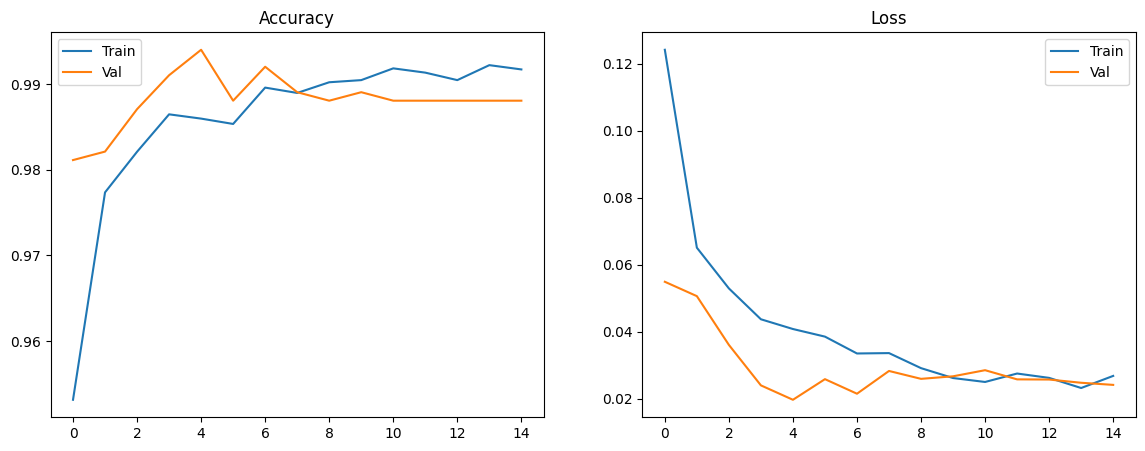


Classification Report:
              precision    recall  f1-score   support

   colon_aca     0.9878    0.9959    0.9918       487
     colon_n     0.9960    0.9881    0.9920       505

    accuracy                         0.9919       992
   macro avg     0.9919    0.9920    0.9919       992
weighted avg     0.9920    0.9919    0.9919       992



In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history["accuracy"], label="Train")
ax1.plot(history.history["val_accuracy"], label="Val")
ax1.set_title("Accuracy")
ax1.legend()

ax2.plot(history.history["loss"], label="Train")
ax2.plot(history.history["val_loss"], label="Val")
ax2.set_title("Loss")
ax2.legend()
plt.show()

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [17]:
print("\nEvaluating model on Test Set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")


Evaluating model on Test Set...
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9919 - loss: 0.0282
Test Accuracy: 0.9919


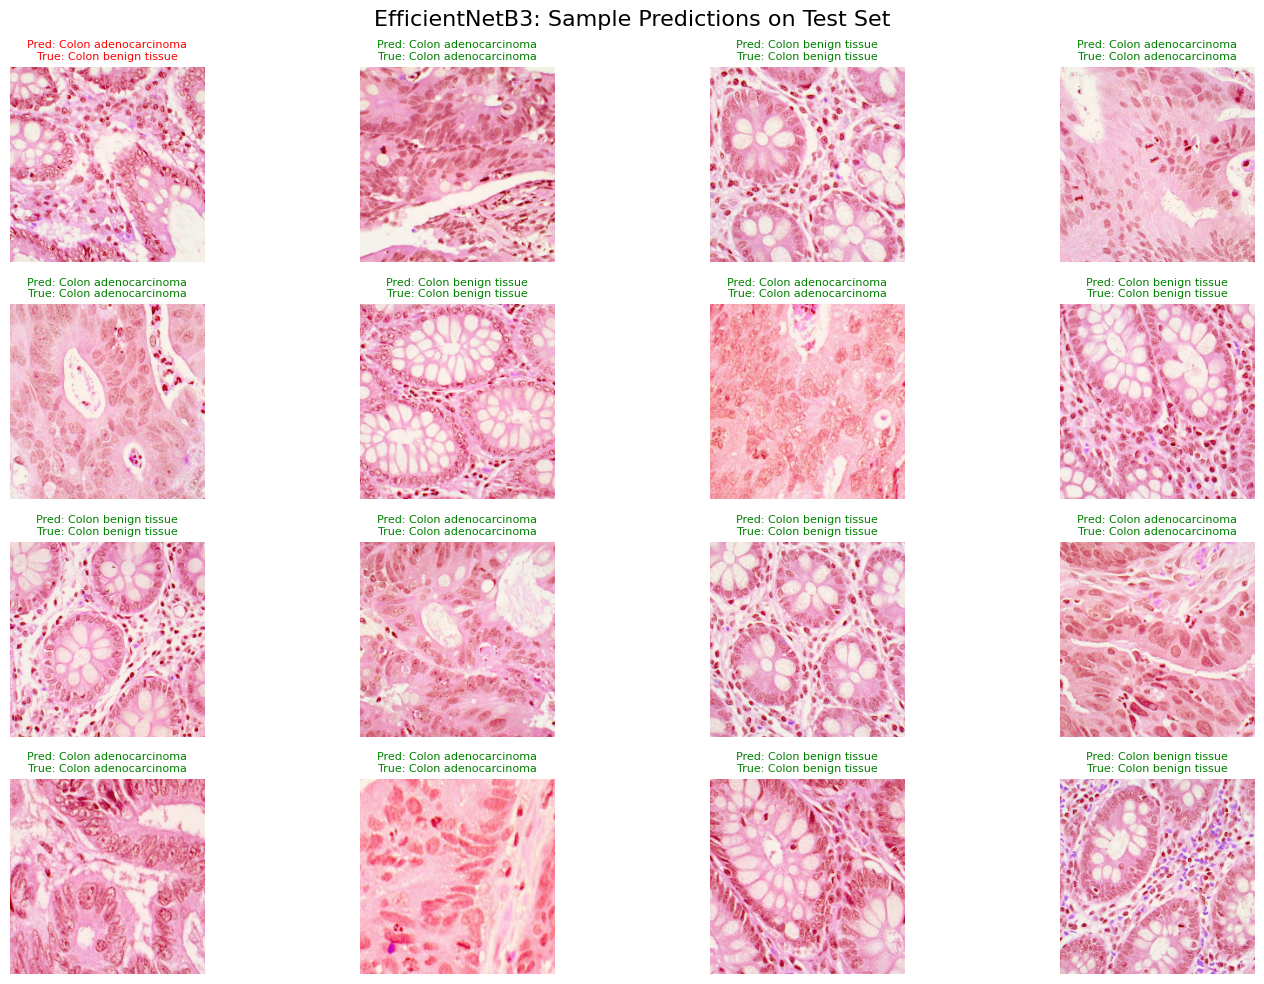

In [18]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Take a batch of 16 images from our pre-split test_ds
# We take from the original test_ds before the manual mapping to see raw images
# Or we can just use the current test_ds and reverse the normalization for display
plt.figure(figsize=(15, 10))

for images, labels in test_ds.take(1):
    # Get predictions for this batch
    pred_probs = model.predict(images, verbose=0)
    pred_classes = np.argmax(pred_probs, axis=1)

    for i in range(min(16, len(images))):
        plt.subplot(4, 4, i + 1)

        # EfficientNet/ResNet preprocessing shifts values;
        # for display, we rescale back to [0, 255] for uint8
        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-5) * 255

        plt.imshow(img.astype("uint8"))
        plt.axis("off")

        true_label = labels[i].numpy()
        pred_label = pred_classes[i]

        true_name = class_names[true_label]
        pred_name = class_names[pred_label]

        # Green if correct, Red if wrong
        color = "green" if pred_label == true_label else "red"

        # Use descriptive names from label_mapping
        title = f"Pred: {label_mapping[pred_name]}\nTrue: {label_mapping[true_name]}"
        plt.title(title, color=color, fontsize=8)

plt.suptitle("EfficientNetB3: Sample Predictions on Test Set", fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
# Save the model with a name indicating the architecture and technique
model.save('best_colon_cancer_efficientnet_transfer_learning.keras')
print("Model saved successfully as 'best_colon_cancer_efficientnet_transfer_learning.keras'")

Model saved successfully as 'best_colon_cancer_efficientnet_transfer_learning.keras'
